In [ ]:
"""
Assignment 2: EDA, Logistic Regression, MLP

Diana Johnson
03-28-2026
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# import and setup data
data_path = "drug_consumption.data"
variables = [ "ID","Age","Gender","Education","Country","Ethnicity", "Nscore","Escore","Oscore","Ascore","Cscore",
            "Impulsive","SS", "Alcohol","Amphet","Amyl","Benzos","Caff","Cannabis","Choc","Coke", "Crack","Ecstasy",
            "Heroin","Ketamine","Legalh","LSD","Meth","Mushrooms","Nicotine","Semer","VSA" ]

data = pd.read_csv(data_path, header=None, names=variables)

In [2]:
## QUESTION 1

# Part A
numeric_vars = [ "Age","Education","Nscore","Escore","Oscore", "Ascore","Cscore","Impulsive","SS"]

# pandas describe() method (via documentation) gives necessary summary information
stats_summary = data[numeric_vars].describe()
stats_summary

# Part B
drugs = ["Alcohol","Cannabis","Ecstasy","Heroin","Nicotine"]
drug_summary = []

for drug in drugs:
    counts = data[drug].value_counts()  # gets the frequency of each class

    # summarize important info
    # nunique(): counts number of classes, idxmax(): gets the index of the max value
    drug_summary.append({
        "Drug": drug,
        "Count": data[drug].count(),
        "Unique Classes": data[drug].nunique(),
        "Most Frequent Class": counts.idxmax(),
        "Freq of Most Freq Class": counts.max()
    })

drug_summary = pd.DataFrame(drug_summary)
drug_summary

# Part C

personality_features = ["Nscore","Escore","Oscore","Ascore","Cscore"]
correlation = data[personality_features].corr()     # corr() calculates pearson by default, but could specify another

correlation


,Nscore,Escore,Oscore,Ascore,Cscore
Nscore,1.000000,-0.431051,0.010177,-0.216964,-0.391088
Escore,-0.431051,1.000000,0.245277,0.157336,0.308024
Oscore,0.010177,0.245277,1.000000,0.038516,-0.056811
Ascore,-0.216964,0.157336,0.038516,1.000000,0.247482
Cscore,-0.391088,0.308024,-0.056811,0.247482,1.000000


In [ ]:
## QUESTION 2
# Part A

def logistic_regression(X, y, alpha, iterations):
    """
    logistic_regression() : performs logistic regression on given input X and y

    Parameters:
        X: np array, feature data
        y: np array, labels
        alpha: learning rate
        iterations: max iterations run without convergence

    Returns:
        theta : np array, weight parameters
    """
    # num of samples
    m = len(y)

    # add bias term to X
    bias = np.ones((m,1))
    X = np.concatenate((bias, X), axis=1)

    # initialize theta
    theta = np.zeros(X.shape[1])

    for i in range(iterations):
        # sigmoid 
        z = np.dot(X, theta)
        h = 1 / (1 + np.exp(-z))

        # calculate gradient
        # np.dot calculates the sum 
        gradient = (1/m) * np.dot((h - y), X)       # transpose x

        # update
        theta = theta - (alpha * gradient)
    
    return theta

# binarize the drug usage variables
# isin returns true/false, astype converts this to 0 and 1
data["DrugUsage"] = data["Cannabis"].isin(["CL3","CL4","CL5","CL6"]).astype(int)

# define x and y
x = data["Impulsive"].values
x = x.reshape(-1,1)     # convert matrix so it is samplesxfeatures

y = data["DrugUsage"].values

theta = logistic_regression(x,y, alpha=0.6, iterations=100)
print(f"Theta 0: {theta[0]}, Theta 1: {theta[1]}\n")

# add bias again for matching dimensions of x and theta
bias = np.ones((len(x),1))
new_x = np.concatenate((bias,x), axis=1)

# compute the hypothesis and apply sigmoid for probabilities
z = np.dot(new_x, theta)
probs = 1 / (1 + np.exp(-z))

# convert probs to binary predictions
y_pred = []
for prob in probs:
    if prob < 0.5:
        y_pred.append(0)
    else:
        y_pred.append(1)


# Part B
def metric_summary(y, y_pred):
    """
    metric_summary() : calculates metrics including accuracy, precision, recall, and F1 score

    Parameters:
        y: np aray, true labels
        y_pred: np array, predicted labels

    Returns:
        TP: true positives
        FP: false positives
        FN: false negatives
        TN: true negatives
    """
    y_pred = np.array(y_pred)
    y_true = np.array(y)

    # find TP, FP, TN, FN
    # initialize all to 0
    TP = TN = FP = FN = 0
    for true, pred in zip(y_true, y_pred):
        if true == 1 and pred == 1:
            TP += 1
        elif true == 0 and pred == 0:
            TN += 1
        elif true == 0 and pred == 1:
            FP += 1
        else:
            FN += 1
    
    # Accuracy
    accuracy = (TP + TN) / len(y_true)

    # Precision (positive predictive value)
    precision = TP / (TP + FP) 

    # Recall (true positive rate)
    recall = TP / (TP + FN) 

    # F1 score
    f1 = 2 * (precision * recall) / (precision + recall)

    # Print everything out report style
    print("Metrics\n==========================\n")
    print(f"Accuracy: {accuracy:.4f}\n")
    print(f"Precision: {precision:.4f}\n")
    print(f"Recall: {recall:.4f}\n")
    print(f"F1 Score: {f1:.4f}\n")
    print("Confusion Matrix:")
    print(f"TP: {TP}, FP: {FP}\n")
    print(f"FN: {FN}, TN: {TN}")

    return TP, FP, FN, TN

# print out metrics
TP, FP, FN, TN = metric_summary(y, y_pred)

Theta 0: 0.1279788463315811, Theta 1: 0.6691604171021216

Metrics

Accuracy: 0.6159

Precision: 0.6483

Recall: 0.6016

F1 Score: 0.6241

Confusion Matrix:
TP: 601, FP: 326

FN: 398, TN: 560


AUC: 0.6680


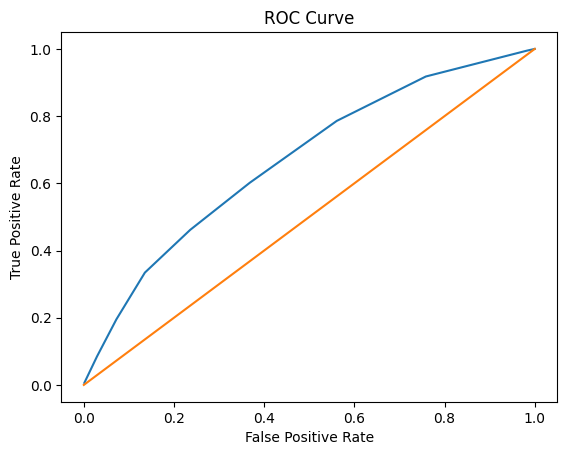

In [ ]:
## Question 3
# Part A

def roc_calc(y, y_pred, probs):
    """
    roc_calc() : calculates and plots the ROC curve and computes the AUC

    Parameters:
        y: np array, real labels
        y_pred: np array, predicted data labels
        probs: np array, predicted probs for positive class (1)

    Returns:
        None
    """
    # true positive rate
    TPR_list = []
    # false positive rate
    FPR_list = []

    # total positives and negatives
    P = np.sum(y == 1)
    N = np.sum(y == 0)

    # sort prob thresholds for ROC
    thresholds = sorted(probs)

    for thresh in thresholds:
        # generate predictions
        y_pred_thresh = []
        for p in probs:
            if p >= thresh:
                y_pred_thresh.append(1)
            else:
                y_pred_thresh.append(0)
        
        # calculate TP, TN, FP, FN
        TP = TN = FP = FN = 0
        for true, pred in zip(y, y_pred_thresh):
            if true == 1 and pred == 1:
                TP += 1
            elif true == 0 and pred == 0:
                TN += 1
            elif true == 0 and pred == 1:
                FP += 1
            else:
                FN += 1
        
        # calculate TPR and FPR
        TPR = TP / P
        FPR = FP / N

        TPR_list.append(TPR)
        FPR_list.append(FPR)

    # sort tpr and fpr lists
    roc_points = list(zip(FPR_list, TPR_list))
    roc_points.sort()

    TPR_sorted = []
    FPR_sorted = []

    for p in roc_points:
        FPR_sorted.append(p[0])
        TPR_sorted.append(p[1])   
        
    # calculate area under the curve
    auc = 0

    # for auc, FPR: X axis, TPR: Y axis
    # calculate trapezoidal area for each segment
    for i in range(1, len(FPR_list)):
        width = FPR_sorted[i] -  FPR_sorted[i-1]
        height = (TPR_sorted[i] + TPR_sorted[i-1]) / 2
        auc += width*height

    print(f"AUC: {auc:.4f}")

    # plot curve
    plt.figure()

    plt.plot(FPR_list, TPR_list, label="ROC Curve")
    plt.plot([0,1],[0,1], label="random classifier")    # need this for the baseline model
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.show()

# call method
roc_calc(y, y_pred, probs)

Theta values: [ 0.2743893  -0.94335544 -0.64919571 -0.48734122 -0.14495055 -0.05596114
 -0.01840331 -0.31130526  0.84292658 -0.34519574  0.66583897]
Metrics

Accuracy: 0.7952

Precision: 0.8087

Recall: 0.8038

F1 Score: 0.8062

Confusion Matrix:
TP: 803, FP: 190

FN: 196, TN: 696
AUC: 0.8755


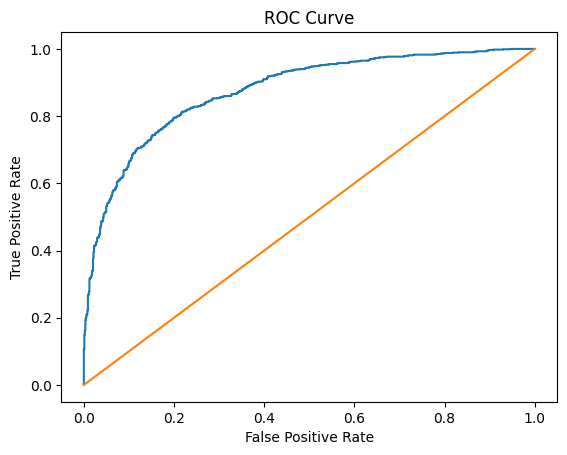

Selected features: ['SS', 'Age', 'Oscore', 'Education', 'Cscore', 'Escore', 'Gender']
Best accuracy: 0.7968169761273209
Metrics

Accuracy: 0.7968

Precision: 0.8092

Recall: 0.8068

F1 Score: 0.8080

Confusion Matrix:
TP: 806, FP: 190

FN: 193, TN: 696
AUC: 0.8749


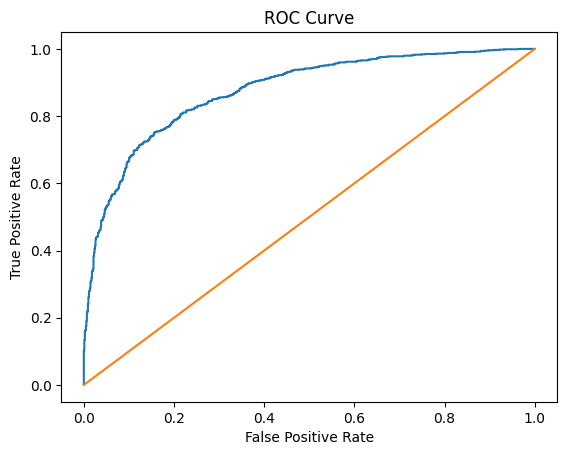

In [5]:
## Question 4
# Part A

features_4a = ["Age","Gender","Education","Nscore","Impulsive","Ascore","Escore","Oscore","Cscore","SS"]

# extract x and y 
X_values = data[features_4a].values
y_values = data["DrugUsage"].values     # still binary from Q3

# logistics regression with all the features for this run
theta_4a = logistic_regression(X_values, y_values, alpha=0.3, iterations=200)
print(f"Theta values: {theta_4a}")

# apply bias to x
bias_4a = np.ones((len(X_values), 1))
X_4a_bias = np.concatenate((bias, X_values), axis=1)

# calculate combinations
z_4a = np.dot(X_4a_bias, theta_4a)
# convert to probs between 0,1
probs_4a = 1 / (1 + np.exp(-z_4a))

# convert probabilities to binary predictions
y_pred_4a = []
for prob in probs_4a:
    if prob < 0.5:
        y_pred_4a.append(0)
    else:
        y_pred_4a.append(1)

# evaluate performance
TP_4a, FP_4a, FN_4a, TN_4a = metric_summary(y_values, y_pred_4a)
roc_calc(y_values, y_pred_4a, probs_4a)

# Part B
# forward selection
forward_features = features_4a.copy()

# list to store features to keep in model
selected_features = []

# track the best accuracy
best_accuracy = 0

# loop adding one feature at a time
for _ in range(len(features_4a)):
    best_feature = None

    # try each remaining feature that has not been selected yet
    for feature in forward_features:
        # create temporary set
        test_features = selected_features + [feature]

        # get data for new test set of features
        X_test = data[test_features].values

        # train logistic regression model on temporary features
        theta_test = logistic_regression(X_test, y_values, alpha=0.6, iterations=200)

        # Add bias term 
        bias = np.ones((len(X_test), 1))
        X_trial_bias = np.concatenate((bias, X_test), axis=1)

        # calculate probabilities
        z_test = np.dot(X_trial_bias, theta_test)
        probs_test = 1 / (1 + np.exp(-z_test))

        # convert probs to binary predictions
        y_pred_test = []
        for p in probs_test:
            if p >= 0.5:
                y_pred_test.append(1)
            else:
                y_pred_test.append(0)
        
        # Compute confusion matrix values
        TP = TN = FP = FN = 0
        for true, pred in zip(y_values, y_pred_test):
            if true == 1 and pred == 1:
                TP += 1
            elif true == 0 and pred == 0:
                TN += 1
            elif true == 0 and pred == 1:
                FP += 1
            else:
                FN += 1
        
        # calculate accuracy
        accuracy = (TP + TN) / len(y_values)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_feature = feature  

    # after testing remaining features, permanently add one that improved accuracy
    if best_feature != None:
        selected_features.append(best_feature)
        forward_features.remove(best_feature)
    else:
        break

print("Selected features:", selected_features)
print("Best accuracy:", best_accuracy)

# Use metrics to compare 4b to 4a
X_selected = data[selected_features].values

# perform logistic regression on the selected features
theta_selected = logistic_regression(X_selected, y_values, alpha=0.6, iterations=200)

# add bias term
bias = np.ones((len(X_selected), 1))
X_selected_bias = np.concatenate((bias, X_selected), axis=1)

# calculate probabilities
z_selected = np.dot(X_selected_bias, theta_selected)
probs_selected = 1 / (1 + np.exp(-z_selected))

# convert probabilities to binary predictions
y_pred_selected = []
for p in probs_selected:
    if p >= 0.5:
        y_pred_selected.append(1)
    else:
        y_pred_selected.append(0)

TP, FP, FN, TN = metric_summary(y_values, y_pred_selected)
roc_calc(y_values, y_pred_selected, probs_selected)

Metrics

Accuracy: 0.7968

Precision: 0.8092

Recall: 0.8068

F1 Score: 0.8080

Confusion Matrix:
TP: 806, FP: 190

FN: 193, TN: 696
AUC: 0.8749


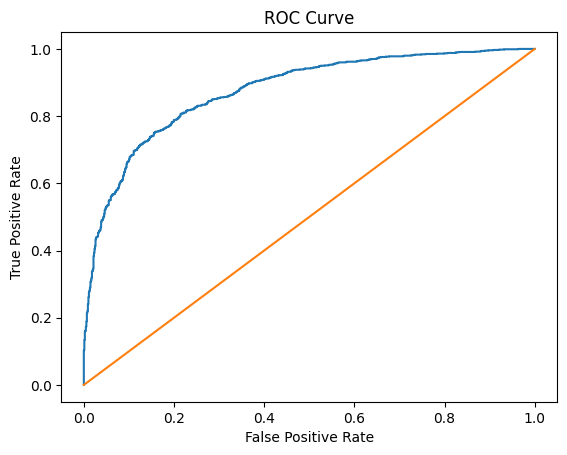

Metrics

Accuracy: 0.7968

Precision: 0.8099

Recall: 0.8058

F1 Score: 0.8078

Confusion Matrix:
TP: 805, FP: 189

FN: 194, TN: 697
AUC: 0.8748


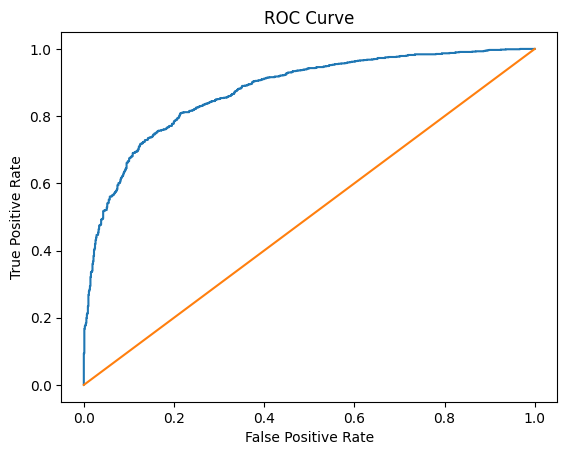

In [ ]:
## Question 5
# Part AI

def logistic_regression_regularization(X, y, alpha, iterations, lam):
    """ 
    logistic_regression_regularization() : performs logistic regression on given input X and y, adds in regularization 

    Parameters:
        X: np array, feature data
        y: np array, labels
        alpha: learning rate
        iterations: max iterations run without convergence
        lam: lambda used for calculating regularization term

    Returns:
        theta : np array, weight parameters
    """
    # num of samples
    m = len(y)

    # add bias term to X
    bias = np.ones((m,1))
    X = np.concatenate((bias, X), axis=1)

    # initialize theta
    theta = np.zeros(X.shape[1])

    for i in range(iterations):
        # sigmoid 
        z = np.dot(X, theta)
        h = 1 / (1 + np.exp(-z))

        # calculate gradient
        # np.dot calculates the sum 
        gradient = (1/m) * np.dot((h - y), X)       # transpose x

        # regularization, exclude bias
        regularization_term = np.zeros_like(theta)
        regularization_term[1:] = (lam/m)*(theta[1:])

        # update
        theta = theta - (alpha * (gradient + regularization_term))
    
    return theta

X_reg = X_selected.copy()
y_reg = y_values.copy()
theta_reg = logistic_regression_regularization(X_reg, y_reg, alpha=0.6, iterations=200, lam=0.5)

# apply bias to x
bias_reg = np.ones((len(X_reg), 1))
X_reg_bias = np.concatenate((bias_reg, X_reg), axis=1)

# calculate combinations
z_reg = np.dot(X_reg_bias, theta_reg)
# convert to probs between 0,1
probs_reg = 1 / (1 + np.exp(-z_reg))

# convert probabilities to binary predictions
y_pred_reg = []
for prob in probs_reg:
    if prob < 0.5:
        y_pred_reg.append(0)
    else:
        y_pred_reg.append(1)

# evaluate performance
TP_reg, FP_reg, FN_reg, TN_reg = metric_summary(y_reg, y_pred_reg)
roc_calc(y_reg, y_pred_reg, probs_reg)

# Part AII  

def normalize_data(data):
    """
    normalize_data() : Scales each feature column to 0-1.

    Parameters:
        data : np array, features

    Returns:
        normalized_data : np array, normalized features
    """

    norm_data = data.copy()

    # for each feature, normalize the data
    # loop columns
    for j in range(data.shape[1]):
        # find min and max of current feature
        f_min = np.min(data[:,j])
        f_max = np.max(data[:,j])

        if f_max - f_min > 0:
            norm_data[:,j] = (data[:,j] - f_min) / (f_max - f_min)
        else:
            norm_data[:,j] = 0.0

    return norm_data
            
    

# scale features and repeat Part AI
X_scaled = normalize_data(X_reg)
theta_scaled = logistic_regression_regularization(X_scaled, y_reg, alpha=0.6, iterations=2000, lam=0.5)

# apply bias to x
bias_scaled = np.ones((len(X_scaled), 1))
X_scaled_bias = np.concatenate((bias_scaled, X_scaled), axis=1)

# calculate combinations
z_scaled = np.dot(X_scaled_bias, theta_scaled)
# convert to probs between 0,1
probs_scaled = 1 / (1 + np.exp(-z_scaled))

# convert probabilities to binary predictions
y_pred_scaled = []
for prob in probs_scaled:
    if prob < 0.5:
        y_pred_scaled.append(0)
    else:
        y_pred_scaled.append(1)

# evaluate performance
TP_scaled, FP_scaled, FN_scaled, TN_scaled = metric_summary(y_reg, y_pred_scaled)
roc_calc(y_reg, y_pred_scaled, probs_scaled)

c:\Users\Diana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


AUC: 0.9439


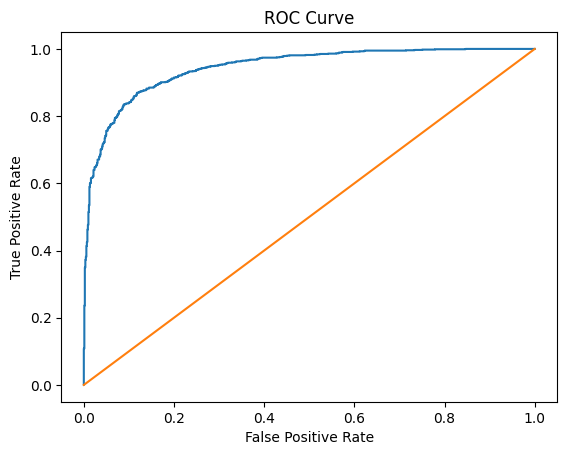

Metrics

Accuracy: 0.8732

Precision: 0.8926

Recall: 0.8649

F1 Score: 0.8785

Confusion Matrix:
TP: 864, FP: 104

FN: 135, TN: 782
Metrics

Accuracy: 0.7936

Precision: 0.8125

Recall: 0.7938

F1 Score: 0.8030

Confusion Matrix:
TP: 793, FP: 183

FN: 206, TN: 703
Metrics

Accuracy: 0.8117

Precision: 0.8313

Recall: 0.8088

F1 Score: 0.8199

Confusion Matrix:
TP: 808, FP: 164

FN: 191, TN: 722


c:\Users\Diana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


Metrics

Accuracy: 0.8393

Precision: 0.8515

Recall: 0.8438

F1 Score: 0.8477

Confusion Matrix:
TP: 843, FP: 147

FN: 156, TN: 739


c:\Users\Diana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


Metrics

Accuracy: 0.8732

Precision: 0.8926

Recall: 0.8649

F1 Score: 0.8785

Confusion Matrix:
TP: 864, FP: 104

FN: 135, TN: 782
Metrics

Accuracy: 0.9894

Precision: 0.9930

Recall: 0.9870

F1 Score: 0.9900

Confusion Matrix:
TP: 986, FP: 7

FN: 13, TN: 879
# Neurons: 5	 Accuracy: 0.793633952254642
# Neurons: 10	 Accuracy: 0.8116710875331565
# Neurons: 50	 Accuracy: 0.8392572944297082
# Neurons: 100	 Accuracy: 0.8732095490716181
# Neurons: 1000	 Accuracy: 0.9893899204244032


c:\Users\Diana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
## Question 6
# Part A

from sklearn.neural_network import MLPClassifier

# use features from 4a
features_nn = ["Age","Gender","Education","Nscore","Impulsive","Ascore","Escore","Oscore","Cscore","SS"]

# extract x and y 
X_nn = data[features_nn].values
y_nn = data["DrugUsage"].values  

# create model
""" 
hidden layer sizes: default 100, number of neurons in hidden layer
activation: relu activation function (preferred from internship experience)
solver: adam optimizer (preferred from internship experience)
learning rate init: initial learning rate/alpha
max iter: max iterations for training
alpha: L2 regularization term, higher helps reduce overfitting
random state: seed for reproducibility
"""
model = MLPClassifier(
    activation='relu',          
    solver='adam',      
    learning_rate_init=0.001,        
    max_iter=400,              
    alpha=0.001,
    random_state=1       
)

# train
model.fit(X_nn, y_nn)

# predict
y_pred_nn = model.predict(X_nn)

# probabilities for ROC
# use all rows in second column for where results are in positive class (y==1 is drug user)
probs_nn = model.predict_proba(X_nn)[:,1]

# Part B
# do ROC AUC
roc_calc(y_nn, y_pred_nn, probs_nn)

# evaluate metrics
TP_nn, FP_nn, FN_nn, TN_nn = metric_summary(y_nn, y_pred_nn)

# Part C
neurons = [5, 10, 50, 100, 1000]
results = []

# remake and train model for all numbers of hidden layers
for n in neurons:
    model = MLPClassifier(
        hidden_layer_sizes=(n,),
        activation='relu',          
        solver='adam',      
        learning_rate_init=0.001,        
        max_iter=400,              
        alpha=0.001,
        random_state=1       
    )

    # train
    model.fit(X_nn, y_nn)

    y_pred = model.predict(X_nn)
    
    # calculate accuracy
    TP, FP, FN, TN = metric_summary(y_nn, y_pred)
    accuracy = (TP + TN) / len(y_nn)
    
    results.append((n, accuracy))

# print final accuracies with number of hidden neurons
for r in results:
    print(f"# Neurons: {r[0]}\t Accuracy: {r[1]}")